## About Dataset
With the rapid growth of digital banking and online transactions, financial institutions increasingly rely on data to understand transaction behavior, detect suspicious activities, and improve risk management.

This dataset contains transaction records that simulate real-world banking activity. It includes information about transaction details, customer demographics, device and channel metadata, as well as security-related indicators.

### Key Features:

- TransactionID: Unique alphanumeric identifier for each transaction.
- AccountID: Unique identifier for each account, with multiple transactions per account.
- TransactionAmount: Monetary value of each transaction, ranging from small everyday expenses to larger purchases.
- TransactionDate: Timestamp of each transaction, capturing date and time.
- TransactionType: Categorical field indicating 'Credit' or 'Debit' transactions.
- Location: Geographic location of the transaction, represented by U.S. city names.
- DeviceID: Alphanumeric identifier for devices used to perform the transaction.
- IP Address: IPv4 address associated with the transaction, with occasional changes for some accounts.
- MerchantID: Unique identifier for merchants, showing preferred and outlier merchants for each account.
- AccountBalance: Balance in the account post-transaction, with logical correlations based on transaction type and amount.
- PreviousTransactionDate: Timestamp of the last transaction for the account, aiding in calculating transaction frequency.
- Channel: Channel through which the transaction was performed (e.g., Online, ATM, Branch).
- CustomerAge: Age of the account holder, with logical groupings based on occupation.
- CustomerOccupation: Occupation of the account holder (e.g., Doctor, Engineer, Student, Retired), reflecting income patterns.
- TransactionDuration: Duration of the transaction in seconds, varying by transaction type.
- LoginAttempts: Number of login attempts before the transaction, with higher values indicating potential anomalies.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import(accuracy_score, confusion_matrix,
classification_report, f1_score, roc_auc_score, average_precision_score)

from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")


In [2]:
import gdown

# Fetch file id on Drive
file_id = "1fNiz9QRSD5drWAs3k1Ji09D_u3COOJWR"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
gdown.download(url, "bank_transactions.csv", quiet=True)

# Load url
bank_df = pd.read_csv("bank_transactions.csv")

# Show first 5 rows
bank_df.head(5)

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


In [3]:
# Dataset size
bank_df.shape

(50000, 15)

In [4]:
# Check for misssing values
bank_df.isnull().sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
TransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


In [5]:
# Check duplicated row
bank_df.duplicated().sum()

np.int64(0)

<br></br>

##### **Exploring column values**

In [6]:
bank_df['LoginAttempts'].unique()

array([1, 3, 5, 2, 4])

In [7]:
bank_df['CustomerOccupation'].unique()

array(['Doctor', 'Student', 'Retired', 'Engineer'], dtype=object)

In [8]:
bank_df['Channel'].unique()

array(['ATM', 'Online', 'Branch'], dtype=object)

In [9]:
bank_df['TransactionType'].unique()

array(['Debit', 'Credit'], dtype=object)

In [10]:
# Total unique transaction duration
bank_df['TransactionDuration'].nunique()

288

In [11]:
# Total unique location
bank_df['Location'].nunique()

43



---



# **Exploratory Data Analysis**

#### Let's explore some major financial and behavioral patterns

In [12]:
# Dataset info
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        50000 non-null  object 
 1   AccountID            50000 non-null  object 
 2   TransactionAmount    50000 non-null  float64
 3   TransactionDate      50000 non-null  object 
 4   TransactionType      50000 non-null  object 
 5   Location             50000 non-null  object 
 6   DeviceID             50000 non-null  object 
 7   IP Address           50000 non-null  object 
 8   MerchantID           50000 non-null  object 
 9   Channel              50000 non-null  object 
 10  CustomerAge          50000 non-null  int64  
 11  CustomerOccupation   50000 non-null  object 
 12  TransactionDuration  50000 non-null  int64  
 13  LoginAttempts        50000 non-null  int64  
 14  AccountBalance       50000 non-null  float64
dtypes: float64(2), int64(3), object(10)


In [13]:
# Summary statistics
bank_df[["AccountBalance", "TransactionAmount"]].describe().round(2)

,AccountBalance,TransactionAmount
count,50000.00,50000.00
mean,5122.74,297.87
std,3904.27,292.82
min,101.25,0.24
25%,1508.72,82.90
50%,4735.41,209.36
75%,7713.67,409.62
max,14977.99,2060.59


In [14]:
# Min and Max values for transaction duration
print("******************************************************************")
print(f"The longest transaction duration spotted in banks was",bank_df['TransactionDuration'].max(), "seconds")
print("")
print(f"The smallest transaction duration spotted in banks was",bank_df['TransactionDuration'].min(), "seconds")
print("******************************************************************")


******************************************************************
The longest transaction duration spotted in banks was 300 seconds

The smallest transaction duration spotted in banks was 10 seconds
******************************************************************


### **Let's investigate if customer's age play a role in transaction duration**

In [15]:
# Locate customers with longest transaction duration (300 seconds)
bank_df.loc[bank_df['TransactionDuration'] ==bank_df['TransactionDuration'].max()]


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
1447,TX001448,AC00080,991.82,12/4/2023 16:16,Debit,Milwaukee,D000496,62.152.134.92,M042,Online,43,Engineer,300,1,3493.13
1803,TX001804,AC00179,216.03,10/27/2023 18:28,Debit,Boston,D000160,90.111.245.138,M042,ATM,42,Doctor,300,1,10462.77
4195,TX004196,AC00080,1008.46,10/10/2024 0:00,Debit,Milwaukee,D000496,62.152.134.92,M042,Online,43,Engineer,300,1,3493.13
5265,TX005266,AC00080,1017.59,11/29/2023 0:00,Debit,Milwaukee,D000496,62.152.134.92,M042,Online,43,Engineer,300,1,3493.13
5308,TX005309,AC00080,1011.04,3/24/2025 0:00,Debit,Milwaukee,D000496,62.152.134.92,M042,Online,43,Engineer,300,1,3493.13
6811,TX006812,AC00080,931.66,7/23/2020,Debit,Milwaukee,D000496,62.152.134.92,M042,Online,43,Engineer,300,1,3493.13
7253,TX007254,AC00080,924.15,10/10/2022,Debit,Milwaukee,D000496,62.152.134.92,M042,Online,43,Engineer,300,1,3493.13
7501,TX007502,AC00080,984.19,4/20/2025,Debit,Milwaukee,D000496,62.152.134.92,M042,Online,43,Engineer,300,1,3493.13
9924,TX009925,AC00080,999.72,12/19/2023,Debit,Milwaukee,D000496,62.152.134.92,M042,Online,43,Engineer,300,1,3493.13
11549,TX011550,AC00179,237.04,7/30/2024,Debit,Boston,D000160,90.111.245.138,M042,ATM,42,Doctor,300,1,10462.77


In [16]:
# Customer age who took exactly 300 seconds to complete a transaction
bank_df[bank_df['TransactionDuration'] == 300]['CustomerAge'].value_counts().reset_index()

,CustomerAge,count
0,43,27
1,42,14


In [17]:
# Locate customer with smallest transaction duration
bank_df[bank_df['TransactionDuration'] == 10]["CustomerAge"].value_counts().reset_index()


,CustomerAge,count
0,31,47
1,67,25
2,27,21
3,48,18
4,39,18


In [18]:
# View Customer age by average duration
bank_df.groupby('CustomerAge')['TransactionDuration'].mean().sort_values(ascending=False).head(10).reset_index()

,CustomerAge,TransactionDuration
0,65,145.120594
1,41,143.197531
2,43,143.024000
3,74,141.347059
4,18,141.137838
5,38,140.078240
6,47,138.089744
7,42,137.057011
8,77,136.654494
9,79,133.354120


## Comment:
Analysis of the longest transaction durations (300 seconds) revealed that  extended transaction times may be driven by specific customer behavior patterns rather than age demographics.

<br></br>

## **Visuals**

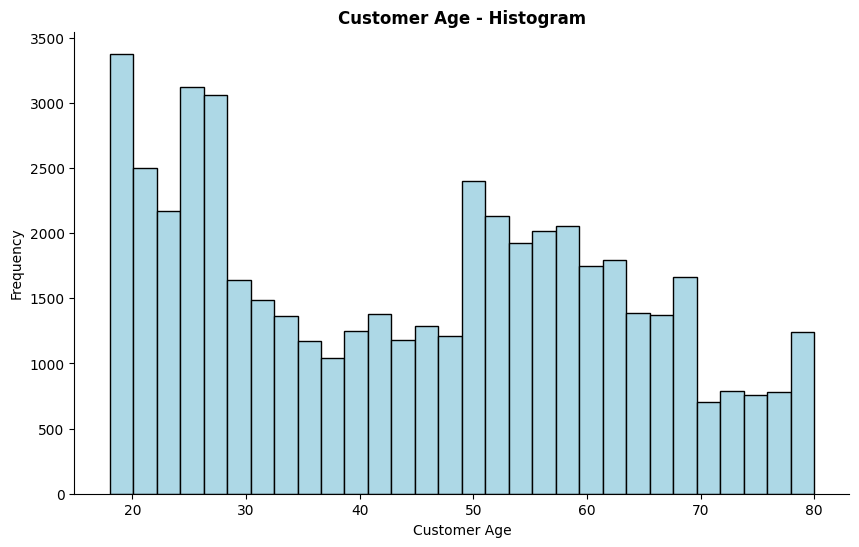

In [19]:
# Visualize Account Balance distribution
plt.figure(figsize=(10,6))
plt.hist(data=bank_df, x="CustomerAge", bins=30, color="lightblue",edgecolor="black")
plt.title("Customer Age - Histogram", fontweight="bold")
plt.ylabel("Frequency")
plt.xlabel("Customer Age")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.show()

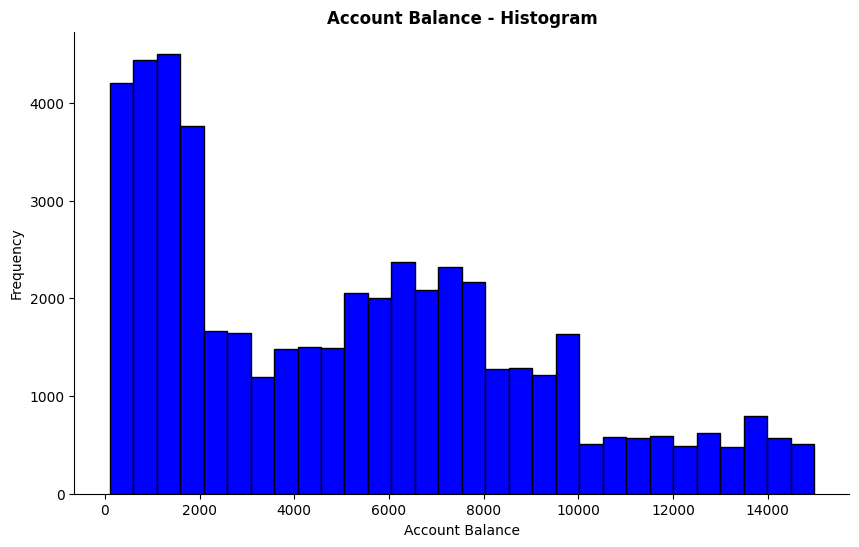

In [20]:
# Visualize Account Balance distribution
plt.figure(figsize=(10,6))
plt.hist(data=bank_df, x="AccountBalance", bins=30, color="blue",edgecolor="black")
plt.title("Account Balance - Histogram", fontweight="bold")
plt.ylabel("Frequency")
plt.xlabel("Account Balance")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.show()

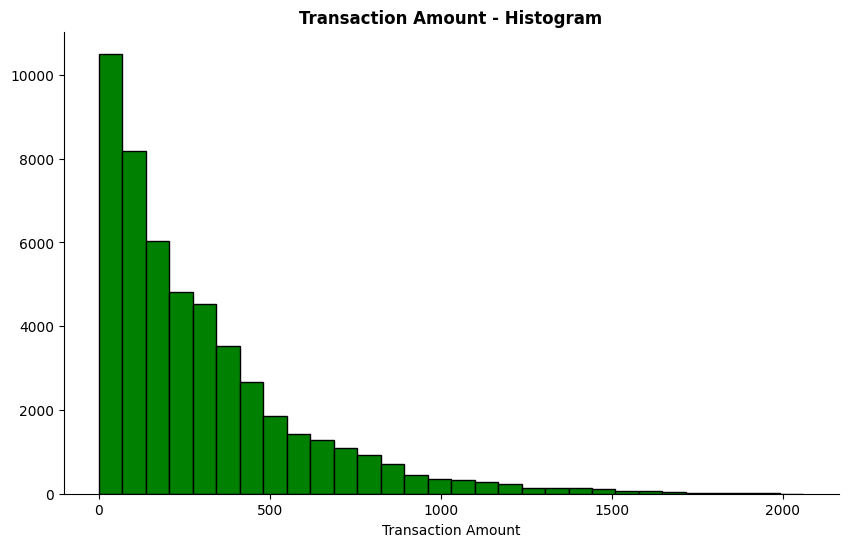

In [21]:
# Visualize Transaction Amount distribution
plt.figure(figsize=(10,6))
plt.hist(data=bank_df, x="TransactionAmount", bins=30, color="green",edgecolor="black")
plt.title("Transaction Amount - Histogram", fontweight="bold")
plt.xlabel("Transaction Amount")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

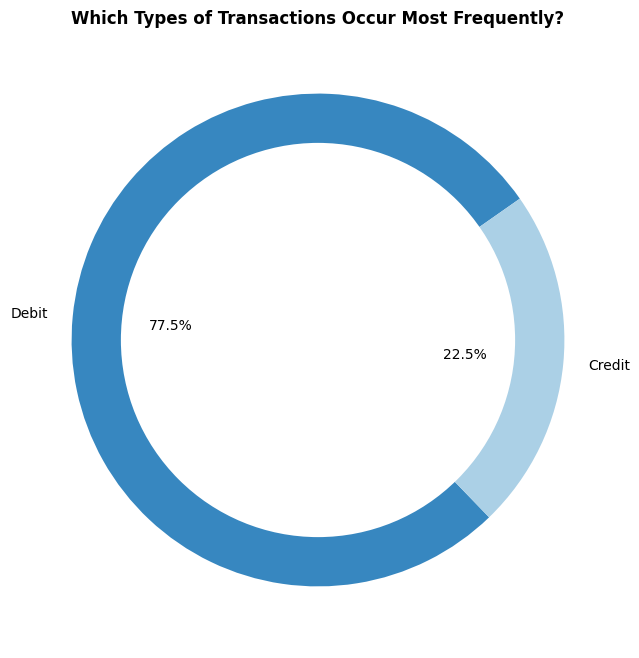

In [22]:
# Count each transaction type
type_counts = bank_df["TransactionType"].value_counts()

# Donut chart
plt.figure(figsize=(10,8))
plt.pie(type_counts.values, labels=type_counts.index, startangle=35, autopct='%1.1f%%', colors=sns.color_palette('Blues_r', len(type_counts)))
plt.gca().add_artist(plt.Circle((0,0), radius=0.8, fc='white'))
plt.title("Which Types of Transactions Occur Most Frequently?", fontweight='bold')
plt.show()

<br></br>

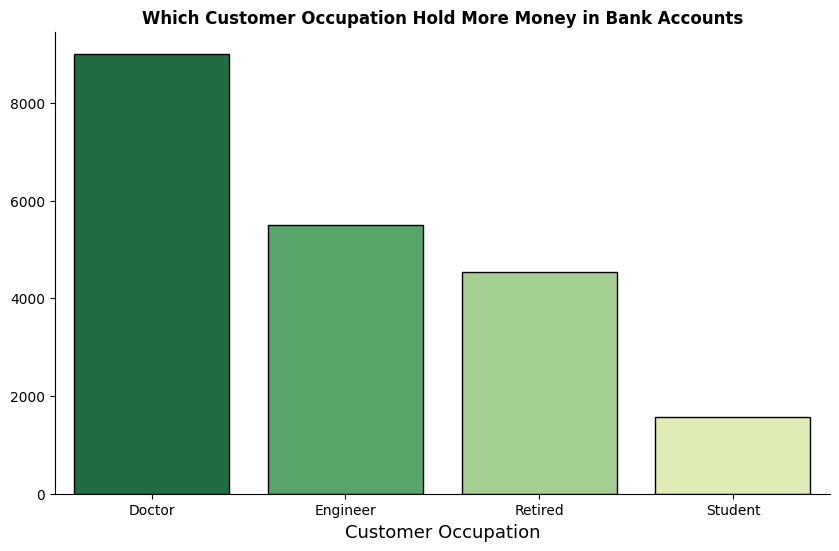

In [23]:
# Group Balance Account by customer occupation
cus_acc = bank_df.groupby("CustomerOccupation")["AccountBalance"].mean().sort_values(ascending=False).reset_index()

# Plot balance account by custumer occupation
plt.figure(figsize=(10,6))
sns.barplot(cus_acc, x ="CustomerOccupation", y ="AccountBalance", palette="YlGn_r", edgecolor="black")
plt.title("Which Customer Occupation Hold More Money in Bank Accounts", fontweight="bold")
plt.xlabel("Customer Occupation", fontsize =13)
plt.ylabel("")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

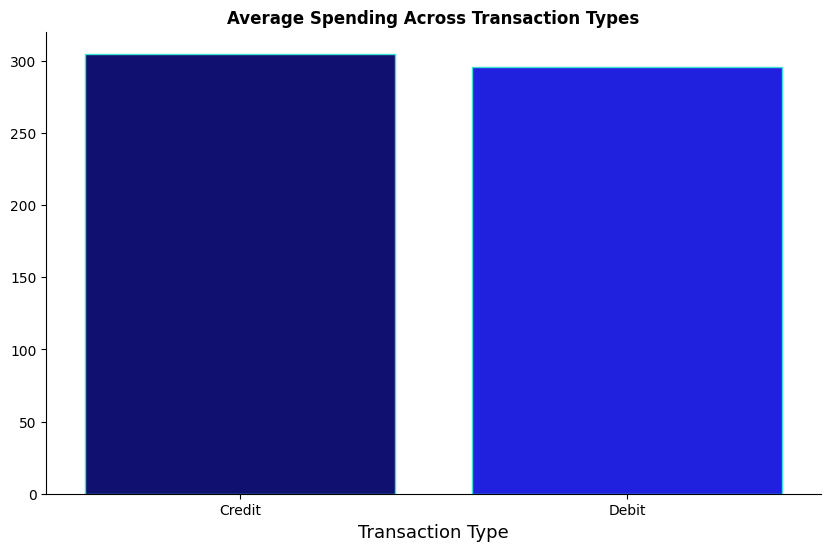

In [24]:
# Group transaction amount by transaction type
transa_type = bank_df.groupby("TransactionType")["TransactionAmount"].mean().sort_values(ascending=False).reset_index()

# Plot average spending by transaction type
plt.figure(figsize=(10,6))
sns.barplot(transa_type, x ="TransactionType", y ="TransactionAmount", palette=["navy","blue"], edgecolor="turquoise")
plt.title("Average Spending Across Transaction Types", fontweight="bold")
plt.ylabel("")
plt.xlabel("Transaction Type", fontsize=13)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

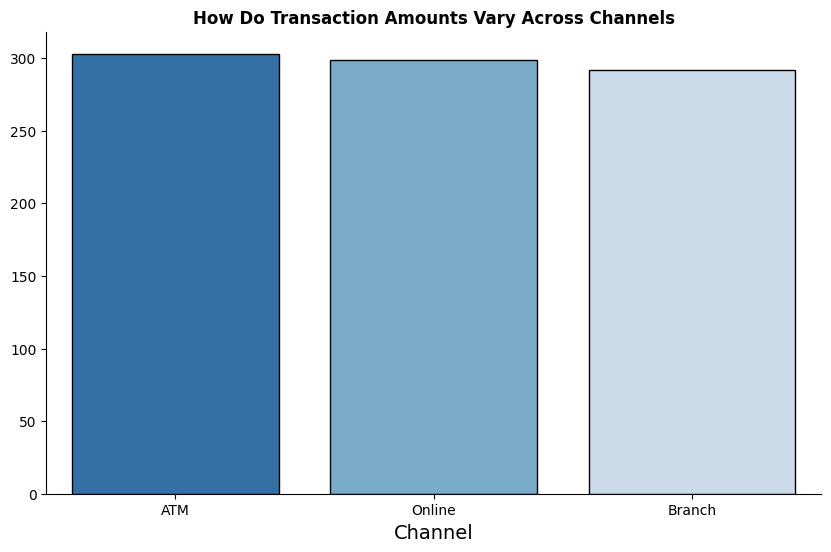

In [25]:
# Group transaction amount by Channel
transa_channel = bank_df.groupby("Channel")["TransactionAmount"].mean().sort_values(ascending=False).reset_index()

# Plot transaction amounts across channels
plt.figure(figsize=(10,6))
sns.barplot(transa_channel, x ="Channel", y ="TransactionAmount", palette="Blues_r", edgecolor="black")
plt.title("How Do Transaction Amounts Vary Across Channels", fontweight="bold")
plt.xlabel("Channel", fontsize =14)
plt.ylabel("")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

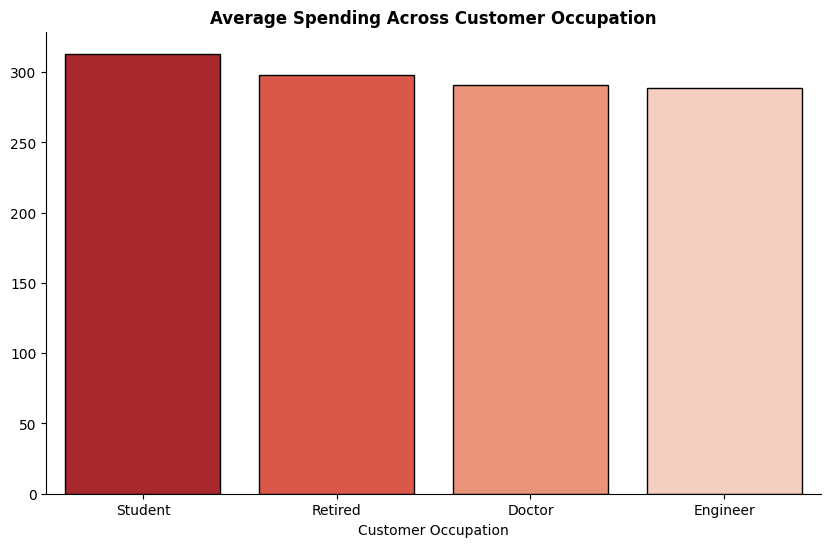

In [26]:
# Group transaction amount by customer occupation
transa_occup = bank_df.groupby("CustomerOccupation")["TransactionAmount"].mean().sort_values(ascending=False).reset_index()

# Plot average spending by transaction type
plt.figure(figsize=(10,6))
sns.barplot(transa_occup, x ="CustomerOccupation", y ="TransactionAmount", palette="Reds_r", edgecolor="black")
plt.title("Average Spending Across Customer Occupation", fontweight="bold")
plt.ylabel("")
plt.xlabel("Customer Occupation")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

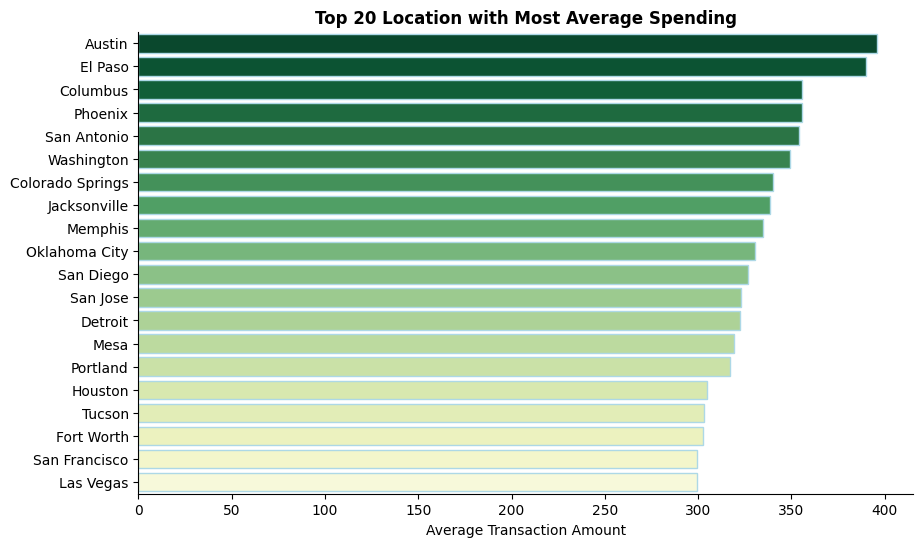

In [27]:
# Group transaction amount by customer occupation
transa_occup = bank_df.groupby("Location")["TransactionAmount"].mean().sort_values(ascending=False).head(20).reset_index()

# Plot average spending by transaction type
plt.figure(figsize=(10,6))
sns.barplot(transa_occup, y ="Location", x ="TransactionAmount", palette="YlGn_r", edgecolor="lightblue")
plt.title("Top 20 Location with Most Average Spending", fontweight="bold")
plt.ylabel("")
plt.xlabel("Average Transaction Amount")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

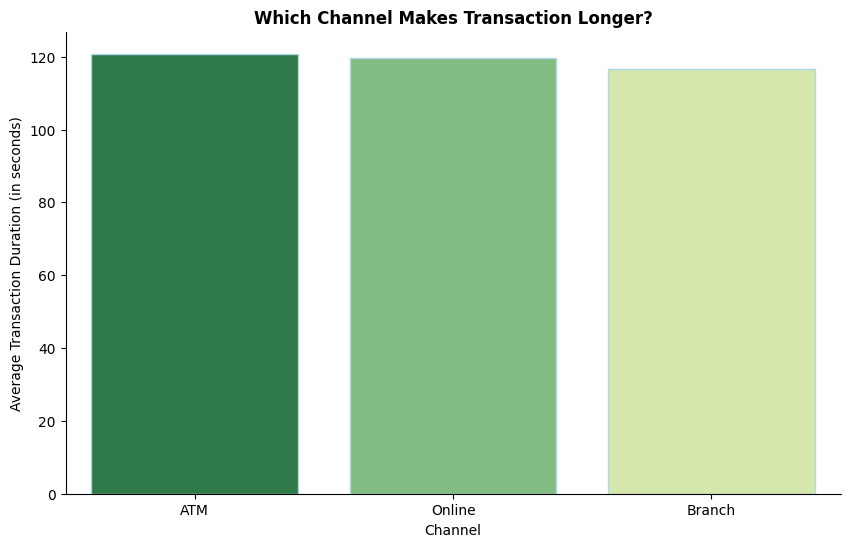

In [28]:
# Group transaction duration by channel
channel_dur = bank_df.groupby('Channel')['TransactionDuration'].mean().sort_values(ascending=False).reset_index()

# Plot
plt.figure(figsize=(10,6))
sns.barplot(channel_dur, x ="Channel", y ="TransactionDuration", palette="YlGn_r", edgecolor="lightblue")
plt.title("Which Channel Makes Transaction Longer?", fontweight="bold")
plt.ylabel("Average Transaction Duration (in seconds)")
plt.xlabel("Channel")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

## Comment:
ATM transactions take longer than Online transactions, suggesting additional authentication or user interaction time.

<br></br>

#### **What Time of the Day Customers Transact Most?**

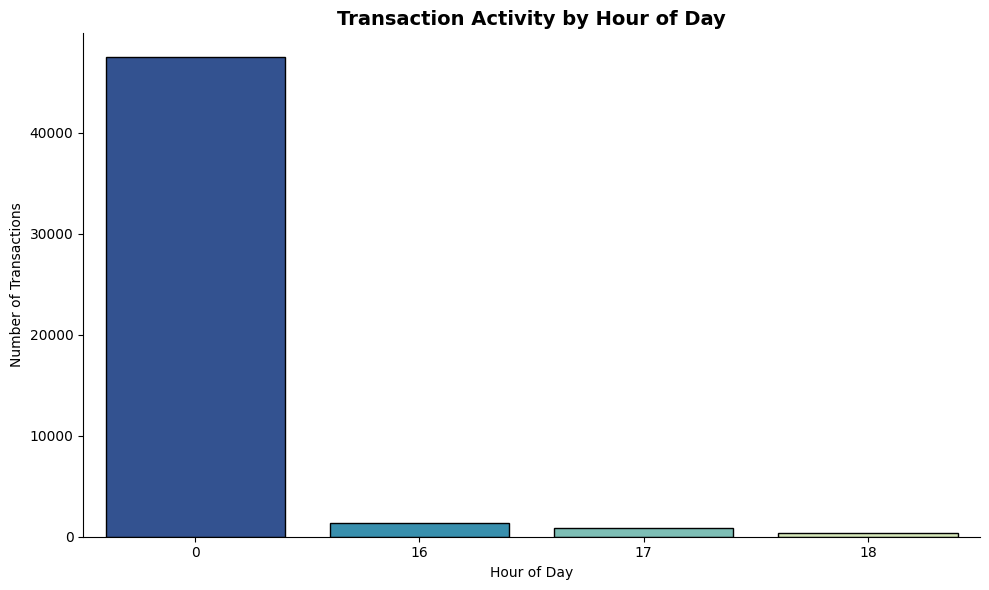

In [29]:
# Date column transformation and feature engineering
bank_df['TransactionDate'] = pd.to_datetime(bank_df['TransactionDate'], format='mixed')
bank_df['Hour'] = bank_df['TransactionDate'].dt.hour

# Count the hours for transactions
hour_counts = (bank_df['Hour'].value_counts().sort_index().reset_index())

# Name tthe columns
hour_counts.columns = ['Hour', 'Transactions']

# Visualize
plt.figure(figsize=(10,6))
sns.barplot(data=hour_counts, x='Hour', y='Transactions',palette='YlGnBu_r', edgecolor='black')

plt.title('Transaction Activity by Hour of Day', fontsize=14,fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=0)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

<br></br>

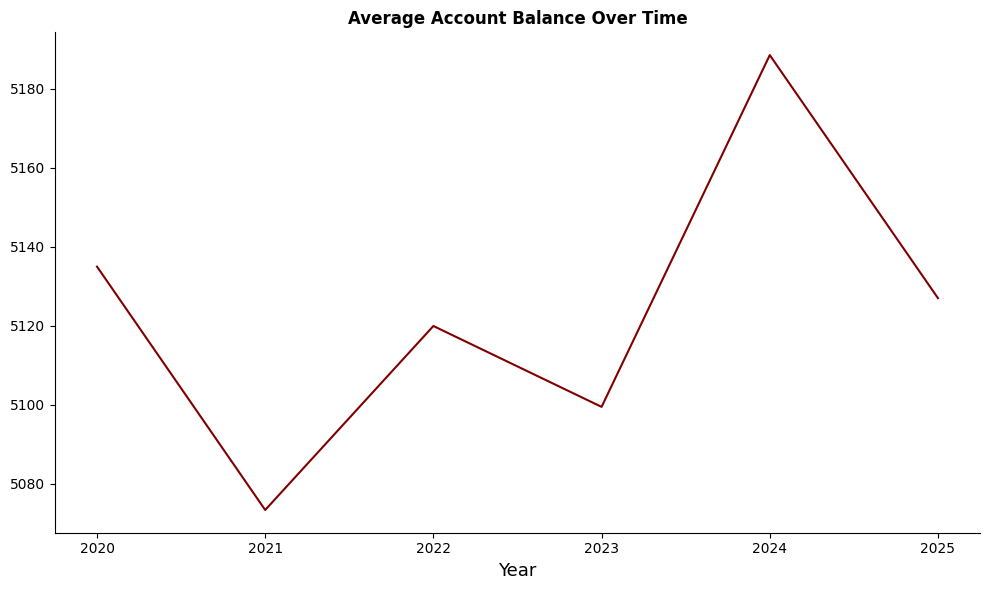

In [30]:
# Fetch only year in transaction date
bank_df['TransactionDate'] = pd.to_datetime(bank_df['TransactionDate'], format='mixed')
bank_df['Year'] = bank_df['TransactionDate'].dt.year

# Group account balances by year
transa_trend = bank_df.groupby("Year")["AccountBalance"].mean().reset_index()

# Plot trend
plt.figure(figsize=(10,6))
sns.lineplot(data=transa_trend, x="Year", y="AccountBalance", color="maroon")
plt.title("Average Account Balance Over Time", fontweight="bold")
plt.ylabel("")
plt.xlabel("Year", fontsize=13)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Comment:
Account balances remained relatively stable between `$4.6K` and `$4.9K` over the six-year period. Overall, the account demonstrates stable liquidity.



---



# **Key Findings**

- Debit transactions dominate activity, accounting for 77.5% of all transactions.
- Credit and Debit transactions have similar average spending levels.
- Transaction amounts are consistent across ATM, Online, and Branch channels.
- Transaction duration shows minimal variation across channels.
- Transaction activity is concentrated at a single recorded hour, indicating a potential data pattern.
- Average account balances remain relatively stable, peaking in 2024.

- Austin and El Paso record the highest average transaction amounts.

- Students exhibit the highest average spending among occupations.

- Doctors maintain the highest average account balances.



